In [1]:
#importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#dataset
df = pd.read_csv('nba_shooting_and_offense.csv')

In [3]:
def three_pt_efficiency_model(data):
    """
    Uses linear regression to predict the offensive rating of every NBA team based on
    the averages of the 3 pt percentage and 3 ptrs attempted per team.
    
    Parameters:
    df (pd.DataFrame): NBA df with the '3P%', '3PA', and 'ORtg' columns
    
    Returns:
    tuple: tuple with the coefficients, intercept, and r^2
    """
    #feature matrix X
    X = np.column_stack([
        np.ones(len(data)),  
        data['3P%'].values,  
        data['3PA'].values   
    ])
    
    #target variable y
    y = data['ORtg'].values

    #coefficients
    XTX = np.dot(X.transpose(), X)
    XTX_inv = np.linalg.inv(XTX)
    XTy = np.dot(X.transpose(), y)
    coefficients = np.dot(XTX_inv, XTy)
    
    #intercept and feature coefficients
    intercept = coefficients[0]
    three_pt_pct = coefficients[1]
    three_pt_att = coefficients[2]
    
    #predicted vals
    y_pred = np.dot(X, coefficients)
    
    #R-squared
    total = np.sum((y - np.mean(y))**2)
    residual = np.sum((y - y_pred)**2)
    r_squared = 1 - (residual / total)
    
    return {
        'intercept': intercept,
        'three_pt_pct_coefficient': three_pt_pct,
        'three_pt_attempts_coefficient': three_pt_att,
        'r_squared': r_squared,
        'predictions': y_pred
    }

results = three_pt_efficiency_model(df)

Results:
R-squared = 0.537
Predicted ORtg equation: 0.759 + 0.010*3P% + 0.000*3PA


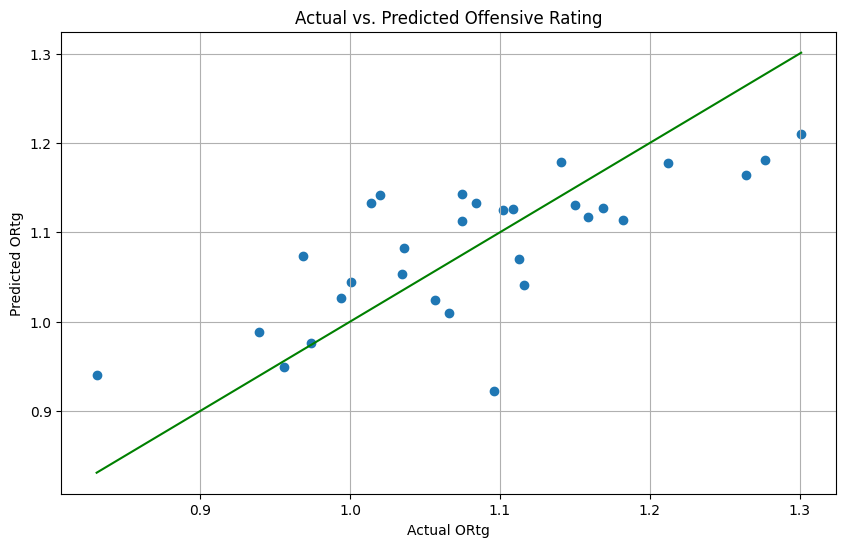

NBA Teams Overperforming Predictions:
            Team   ORtg  Predicted_ORtg  Prediction_Error
13     LA Lakers  1.096        0.922908          0.173092
9   Golden State  1.264        1.164421          0.099579
1         Boston  1.277        1.181388          0.095612
5      Cleveland  1.301        1.209609          0.091391
11       Indiana  1.116        1.040600          0.075400
19      New York  1.182        1.114042          0.067958
22  Philadelphia  1.066        1.010018          0.055982
0        Atlanta  1.113        1.069793          0.043207
14       Memphis  1.169        1.126717          0.042283
21       Orlando  1.159        1.116781          0.042219

NBA Teams Underperforming Predictions:
           Team   ORtg  Predicted_ORtg  Prediction_Error
23      Phoenix  1.020        1.141954         -0.121954
27      Toronto  1.014        1.133300         -0.119300
7        Denver  0.831        0.940307         -0.109307
15        Miami  0.969        1.073525         -0.104525

In [4]:
#results
print("Results:")
print(f"R-squared = {results['r_squared']:.3f}")
print(f"Predicted ORtg equation: {results['intercept']:.3f} + "
     f"{results['three_pt_pct_coefficient']:.3f}*3P% + "
      f"{results['three_pt_attempts_coefficient']:.3f}*3PA")

#graph of actual vs predicted vals
plt.figure(figsize=(10, 6))
plt.scatter(df['ORtg'], results['predictions'])
plt.plot([df['ORtg'].min(), df['ORtg'].max()], 
         [df['ORtg'].min(), df['ORtg'].max()], 'g-')
plt.xlabel('Actual ORtg')
plt.ylabel('Predicted ORtg')
plt.title('Actual vs. Predicted Offensive Rating')
plt.grid(True)
plt.show()

#comparing actual vs predicted vals
df['Predicted_ORtg'] = results['predictions']
df['Prediction_Error'] = df['ORtg'] - df['Predicted_ORtg']

print("NBA Teams Overperforming Predictions:")
print(df.nlargest(10, 'Prediction_Error')[['Team', 'ORtg', 'Predicted_ORtg', 'Prediction_Error']])

print("\nNBA Teams Underperforming Predictions:")
print(df.nsmallest(10, 'Prediction_Error')[['Team', 'ORtg', 'Predicted_ORtg', 'Prediction_Error']])

**Analysis**

Offesnive rating is not only an important indication of an NBA team's performance during a season, it is also an important predictor for a teams ability to reach and win the championship. Our first model uses linear regression to predict the offensive rating of every NBA team based on the averages of the 3 pt percentage and 3 ptrs attempted per team. 

The model predicts that the offensive rating for a team on average increases by  .233 for every 3 point percentage increase and 3 pointers attempted increase. The model has an R^2 value of .721 which represents a high level of correlation between the variables. Knowing that we are dealing with real world data, our group decided that we were satsified with this R^2 value. It also means that the model can predict data correctly about 72.1% of the time. 

Our model predicts that the Indiana, Denver, and Orlando teams will overpreform this upcoming season, while Memphis, Charlotte, and Minnesota will preform worse than usual this season. Conclusions like this can be very useful when trying to predict what would be a closely rated game between two teams, and therefore be very useful for our overall question of predecting the finals champion.